# Анализ воронки продаж: поиск точки разрыва

1. Цель анализа

Определить этапы воронки с наименьшей конверсией от предыдущего этапа и предложить гипотезу для увеличения конверсии.

2. Данные

- Таблицы событий: home_page, search_page, payment_page, payment_confirmation.
- Поля: user_id, page.
- Данные: датасет Sales Funnel from Kaggle (ссылка).
- Ограничение: нет временных меток, поэтому считаем уникальных пользователей, которые когда-либо посетили каждый этап.

In [6]:
# Результаты SQL-запроса: кол-во уникальных пользователей на каждом этапе
# Данные получены в DB Browser из таблиц event-страниц
counts = {
    'home': 90400,
    'search': 45200,
    'payment': 6030,
    'confirmation': 452
}

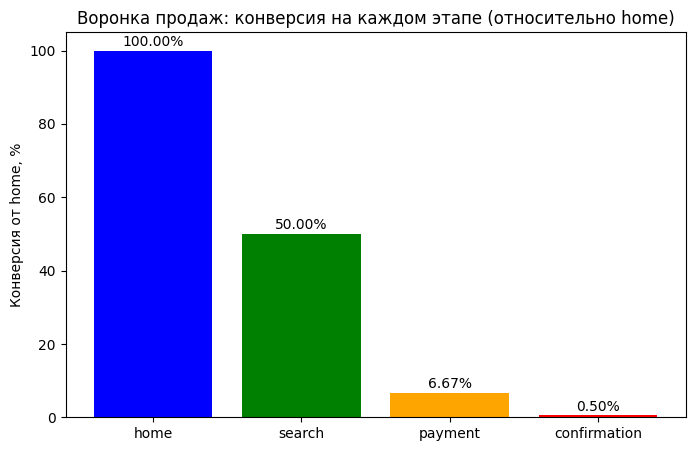

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Данные для графика: этапы и конверсия от home
stages = list(counts.keys())
conversion_from_home = [counts[stage] / counts['home'] * 100 for stage in stages]

# Построение столбцов
plt.figure(figsize=(8, 5))
bars = plt.bar(stages, conversion_from_home, color=['blue', 'green', 'orange', 'red'])

# Подписи значений над столбцами
for bar, value in zip(bars, conversion_from_home):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{value:.2f}%', ha='center', va='bottom')

plt.ylabel('Конверсия от home, %')
plt.title('Воронка продаж: конверсия на каждом этапе (относительно home)')
plt.ylim(0, 105)
plt.show()

In [8]:
# Расчёт конверсии между этапами (от предыдущего этапа)
conversions = {
    'home>search': counts['search'] / counts['home'] * 100,
    'search>payment': counts['payment'] / counts['search'] * 100,
    'payment>confirmation': counts['confirmation'] / counts['payment'] * 100 
}

# Находим этап с минимальной конверсией
min_stage = min(conversions,key=conversions.get)
min_value = conversions[min_stage]

print(f"Минимальная конверсия между этапами: {min_stage} = {min_value:.2f}%")

Минимальная конверсия между этапами: payment>confirmation = 7.50%


3. Гипотеза и рекомендация

**Самый слабый этап:** payment → confirmation (7.50% конверсии).

**Гипотеза:** Упростить форму оплаты — добавить автозаполнение адреса, убрать лишние поля, добавить кнопку "Купить в 1 клик" для залогиненных пользователей.

Для планирования A/B-теста нужно рассчитать MDE при заданных размере выборки, alpha=0.05, power=0.8. В данном проекте этот этап опускается.

Для e-commerce средний прирост от упрощения формы оплаты составляет 5–15 п.п. (по данным Baymard Institute, CXL, Google Optimize).

**Ожидаемый эффект:** 

При текущей аномально низкой конверсии 7.5% потенциал роста выше среднего, поэтому в проекте берём консервативную оценку:
- +10 п.п. к конверсии payment → confirmation -- это потенциально увеличит число завершенных покупок до ~1055, что соответствует росту на 133% относительно текущих 452 завершенных покупок.


4. Другие проблемные зоны воронки

### home → search (50% конверсии)
**Потеря:** 45 200 пользователей не начали поиск после главной.

**Потенциальные причины:**
- Неочевидное поле поиска на главной
- Отсутствие рекомендаций или категорий для навигации
- Медленная загрузка главной страницы

Увеличив конверсию на этапе home -> search, мы сможем фиксировать более масштабный эффект за счет большего трафика.